# Tutorial 13 — Denoising Autoencoder

## Objective

This notebook implements **Tutorial 13: Denoising Autoencoders** using PyTorch.

The tutorial covers:

- Loading and preprocessing the MNIST dataset
- Adding random noise to images
- Building a denoising autoencoder
- Training the model to reconstruct clean images from noisy images
- Visualizing noisy and reconstructed results
- Implementing a deeper denoising autoencoder
- Implementing a Variational Autoencoder (VAE)

The main tasks are:

1. Implement the deep autoencoder
2. Implement the variational autoencoder


## 1. Import Required Libraries

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Preprocess the MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images.

Each image has size:

\[
28 \times 28
\]

In a denoising autoencoder:

- Input = noisy image
- Target = original clean image

The model learns to remove noise and reconstruct the clean image.


In [2]:
transform = transforms.ToTensor()

train_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_full_dataset))
print("Testing samples:", len(test_dataset))
print("Image shape:", train_full_dataset[0][0].shape)


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Training samples: 60000
Testing samples: 10000
Image shape: torch.Size([1, 28, 28])


## 3. Create DataLoaders

A subset is used by default to keep training time practical.

Set `USE_SUBSET = False` if you want to train on the full MNIST dataset.


In [3]:
USE_SUBSET = True
TRAIN_SUBSET_SIZE = 20000
TEST_SUBSET_SIZE = 5000

batch_size = 128

if USE_SUBSET:
    train_indices = np.arange(TRAIN_SUBSET_SIZE)
    test_indices = np.arange(TEST_SUBSET_SIZE)

    train_dataset = Subset(train_full_dataset, train_indices)
    test_dataset_used = Subset(test_dataset, test_indices)
else:
    train_dataset = train_full_dataset
    test_dataset_used = test_dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset_used,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training samples used:", len(train_dataset))
print("Testing samples used:", len(test_dataset_used))


Training samples used: 20000
Testing samples used: 5000


## 4. Add Noise to Images

Random Gaussian noise is added to the images.

The noisy image is clipped to keep pixel values in the range:

\[
0 \leq x \leq 1
\]


In [4]:
def add_noise(images, noise_factor=0.5):
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    return noisy_images


## 5. Visualize Clean and Noisy Images

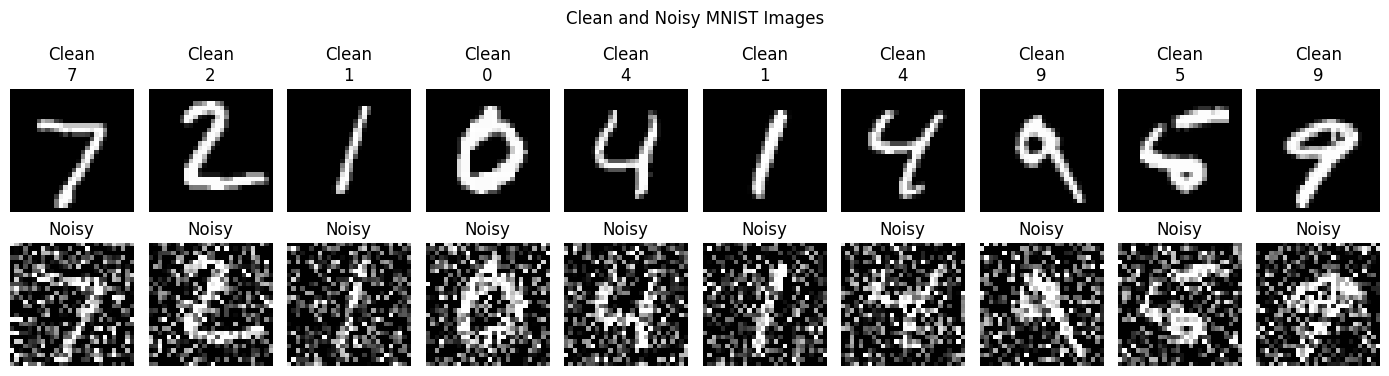

In [5]:
def show_clean_noisy_samples(dataset, n_images=10, noise_factor=0.5):
    plt.figure(figsize=(14, 4))

    for i in range(n_images):
        clean_image, label = dataset[i]
        noisy_image = add_noise(clean_image.unsqueeze(0), noise_factor=noise_factor).squeeze(0)

        plt.subplot(2, n_images, i + 1)
        plt.imshow(clean_image.squeeze(), cmap="gray")
        plt.title(f"Clean\n{label}")
        plt.axis("off")

        plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(noisy_image.squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

    plt.suptitle("Clean and Noisy MNIST Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_13_clean_noisy_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_clean_noisy_samples(test_dataset_used, n_images=10, noise_factor=0.5)


# Part A — Basic Denoising Autoencoder

The denoising autoencoder receives a noisy image and tries to reconstruct the clean image.


In [6]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # 14x14 -> 7x7
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 7x7 -> 14x14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # 14x14 -> 28x28
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


basic_dae = DenoisingAutoencoder().to(device)
print(basic_dae)


DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


## 6. Training and Evaluation Functions

In [7]:
def train_denoising_autoencoder(
    model,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001,
    noise_factor=0.5
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_total = 0

        for clean_images, _ in train_loader:
            clean_images = clean_images.to(device)
            noisy_images = add_noise(clean_images, noise_factor=noise_factor)

            reconstructed = model(noisy_images)
            loss = criterion(reconstructed, clean_images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * clean_images.size(0)
            train_total += clean_images.size(0)

        train_loss = train_loss / train_total

        model.eval()
        test_loss = 0.0
        test_total = 0

        with torch.no_grad():
            for clean_images, _ in test_loader:
                clean_images = clean_images.to(device)
                noisy_images = add_noise(clean_images, noise_factor=noise_factor)

                reconstructed = model(noisy_images)
                loss = criterion(reconstructed, clean_images)

                test_loss += loss.item() * clean_images.size(0)
                test_total += clean_images.size(0)

        test_loss = test_loss / test_total

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Test Loss: {test_loss:.6f}"
        )

    total_time = time.time() - start_time

    return history, total_time


def plot_loss_curves(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def visualize_denoising_results(model, dataset, filename, n_images=10, noise_factor=0.5):
    model.eval()

    plt.figure(figsize=(14, 6))

    with torch.no_grad():
        for i in range(n_images):
            clean_image, _ = dataset[i]
            noisy_image = add_noise(clean_image.unsqueeze(0), noise_factor=noise_factor)
            reconstructed = model(noisy_image.to(device)).cpu().squeeze()

            plt.subplot(3, n_images, i + 1)
            plt.imshow(clean_image.squeeze(), cmap="gray")
            plt.title("Clean")
            plt.axis("off")

            plt.subplot(3, n_images, i + 1 + n_images)
            plt.imshow(noisy_image.squeeze(), cmap="gray")
            plt.title("Noisy")
            plt.axis("off")

            plt.subplot(3, n_images, i + 1 + 2 * n_images)
            plt.imshow(reconstructed, cmap="gray")
            plt.title("Denoised")
            plt.axis("off")

    plt.suptitle("Clean vs Noisy vs Denoised Images")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 7. Train the Basic Denoising Autoencoder

In [8]:
torch.manual_seed(SEED)

basic_dae = DenoisingAutoencoder().to(device)

basic_history, basic_time = train_denoising_autoencoder(
    basic_dae,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001,
    noise_factor=0.5
)

print("Basic denoising autoencoder training time:", round(basic_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(basic_dae))


Epoch 1/5 | Train Loss: 0.103937 | Test Loss: 0.048241
Epoch 2/5 | Train Loss: 0.034437 | Test Loss: 0.022287
Epoch 3/5 | Train Loss: 0.020088 | Test Loss: 0.019065
Epoch 4/5 | Train Loss: 0.017871 | Test Loss: 0.017480
Epoch 5/5 | Train Loss: 0.016825 | Test Loss: 0.016517
Basic denoising autoencoder training time: 16.03 seconds
Trainable parameters: 29249


## 8. Plot Basic Denoising Autoencoder Loss Curve

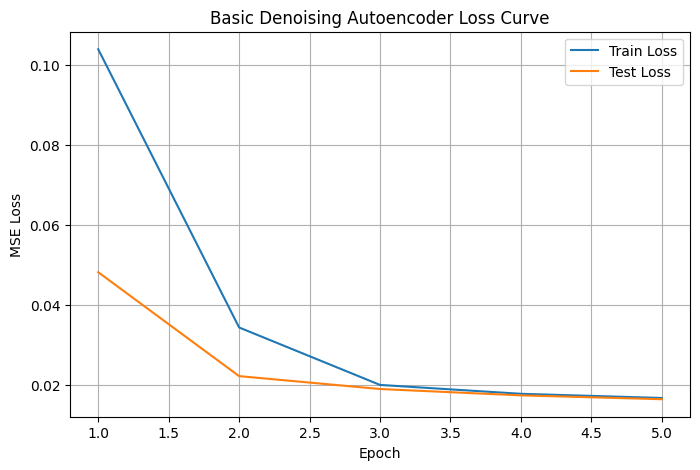

In [9]:
plot_loss_curves(
    basic_history,
    "Basic Denoising Autoencoder Loss Curve",
    "images/tutorial_13_basic_dae_loss.png"
)


## 9. Visualize Basic Denoising Results

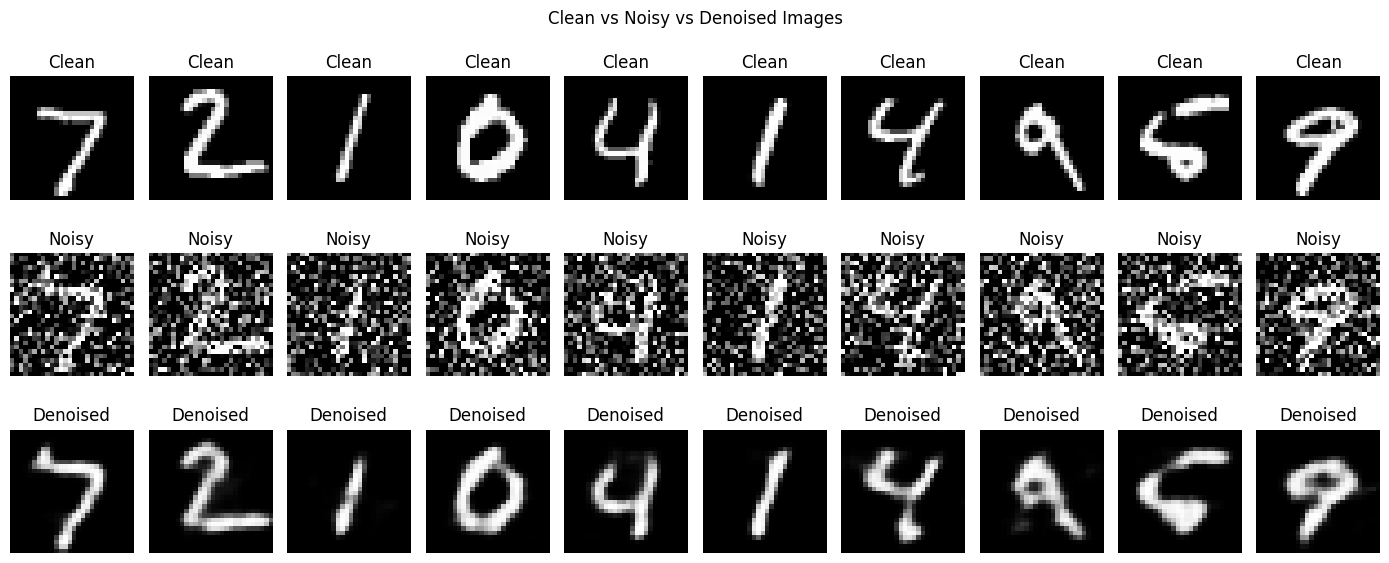

In [10]:
visualize_denoising_results(
    basic_dae,
    test_dataset_used,
    filename="images/tutorial_13_basic_denoising_results.png",
    n_images=10,
    noise_factor=0.5
)


# Part B — Deep Denoising Autoencoder

The task asks to implement a deep autoencoder.

The deep denoising autoencoder uses:

- More convolutional layers
- More feature channels
- Batch normalization
- A deeper encoder and decoder

The goal is to improve denoising quality and reduce reconstruction loss.


In [11]:
class DeepDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 14x14 -> 7x7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 7x7 -> 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # 14x14 -> 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


deep_dae = DeepDenoisingAutoencoder().to(device)
print(deep_dae)
print("Trainable parameters:", count_trainable_parameters(deep_dae))


DeepDenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1

## 10. Train the Deep Denoising Autoencoder

In [12]:
torch.manual_seed(SEED)

deep_dae = DeepDenoisingAutoencoder().to(device)

deep_history, deep_time = train_denoising_autoencoder(
    deep_dae,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001,
    noise_factor=0.5
)

print("Deep denoising autoencoder training time:", round(deep_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(deep_dae))


Epoch 1/5 | Train Loss: 0.032758 | Test Loss: 0.013568
Epoch 2/5 | Train Loss: 0.011455 | Test Loss: 0.011054
Epoch 3/5 | Train Loss: 0.010696 | Test Loss: 0.010773
Epoch 4/5 | Train Loss: 0.010340 | Test Loss: 0.010470
Epoch 5/5 | Train Loss: 0.010131 | Test Loss: 0.010034
Deep denoising autoencoder training time: 19.28 seconds
Trainable parameters: 222561


## 11. Plot Deep Denoising Autoencoder Loss Curve

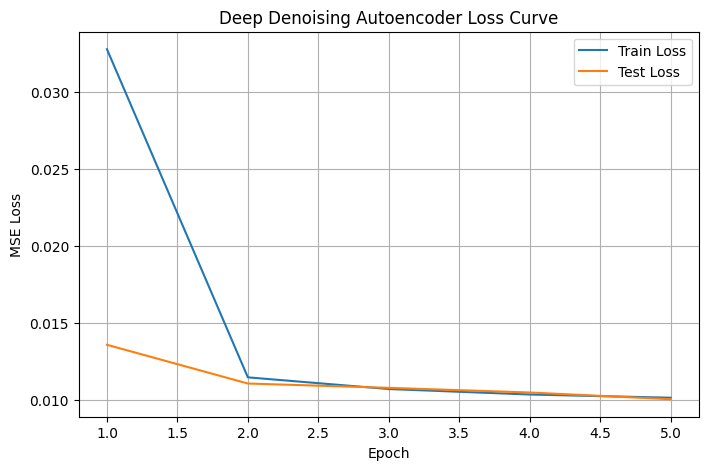

In [13]:
plot_loss_curves(
    deep_history,
    "Deep Denoising Autoencoder Loss Curve",
    "images/tutorial_13_deep_dae_loss.png"
)


## 12. Visualize Deep Denoising Results

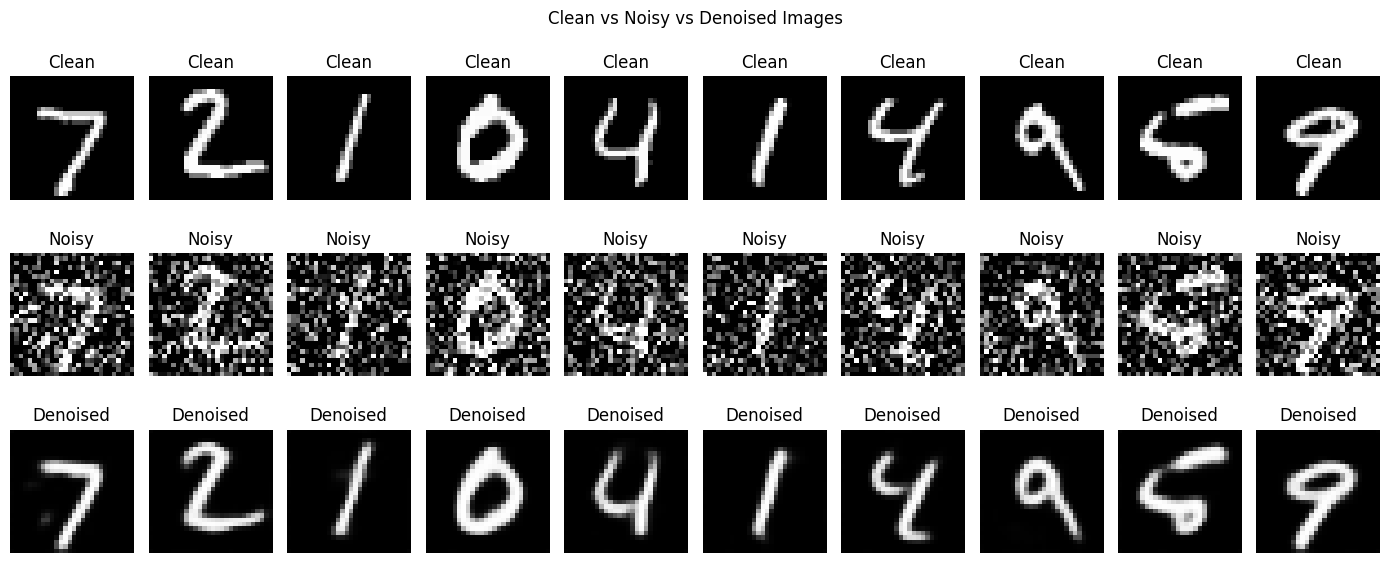

In [14]:
visualize_denoising_results(
    deep_dae,
    test_dataset_used,
    filename="images/tutorial_13_deep_denoising_results.png",
    n_images=10,
    noise_factor=0.5
)


# Part C — Variational Autoencoder (VAE)

The second task asks to implement a variational autoencoder.

A VAE learns a probabilistic latent space.

Instead of encoding an image into one fixed vector, the encoder predicts:

- Mean vector: `mu`
- Log variance vector: `logvar`

Then a latent vector is sampled using the reparameterization trick.


In [15]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )

        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 7x7 -> 14x14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # 14x14 -> 28x28
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


vae = VariationalAutoencoder(latent_dim=16).to(device)
print(vae)
print("Trainable parameters:", count_trainable_parameters(vae))


VariationalAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_mu): Linear(in_features=3136, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=16, bias=True)
  (fc_decode): Linear(in_features=16, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)
Trainable parameters: 182945


## 13. VAE Loss Function

The VAE loss has two parts:

1. Reconstruction loss
2. KL divergence loss

The reconstruction loss helps generate images similar to the input.

The KL divergence loss makes the latent space follow a normal distribution.


In [16]:
def vae_loss_function(reconstructed, clean_images, mu, logvar):
    reconstruction_loss = F.mse_loss(reconstructed, clean_images, reduction="sum")
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = reconstruction_loss + kl_divergence

    return total_loss, reconstruction_loss, kl_divergence


## 14. Train the VAE as a Denoising Model

The VAE receives noisy images and tries to reconstruct the clean images.


In [17]:
def train_vae(
    model,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001,
    noise_factor=0.5
):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_recon_loss": [],
        "train_kl_loss": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon_loss = 0.0
        train_kl_loss = 0.0
        train_total = 0

        for clean_images, _ in train_loader:
            clean_images = clean_images.to(device)
            noisy_images = add_noise(clean_images, noise_factor=noise_factor)

            reconstructed, mu, logvar = model(noisy_images)
            loss, recon_loss, kl_loss = vae_loss_function(reconstructed, clean_images, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            train_total += clean_images.size(0)

        train_loss = train_loss / train_total
        train_recon_loss = train_recon_loss / train_total
        train_kl_loss = train_kl_loss / train_total

        model.eval()
        test_loss = 0.0
        test_total = 0

        with torch.no_grad():
            for clean_images, _ in test_loader:
                clean_images = clean_images.to(device)
                noisy_images = add_noise(clean_images, noise_factor=noise_factor)

                reconstructed, mu, logvar = model(noisy_images)
                loss, _, _ = vae_loss_function(reconstructed, clean_images, mu, logvar)

                test_loss += loss.item()
                test_total += clean_images.size(0)

        test_loss = test_loss / test_total

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_recon_loss"].append(train_recon_loss)
        history["train_kl_loss"].append(train_kl_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Recon Loss: {train_recon_loss:.4f} | "
            f"KL Loss: {train_kl_loss:.4f}"
        )

    total_time = time.time() - start_time

    return history, total_time


In [18]:
torch.manual_seed(SEED)

vae = VariationalAutoencoder(latent_dim=16).to(device)

vae_history, vae_time = train_vae(
    vae,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001,
    noise_factor=0.5
)

print("VAE training time:", round(vae_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(vae))


Epoch 1/5 | Train Loss: 70.8660 | Test Loss: 49.6362 | Recon Loss: 67.0345 | KL Loss: 3.8315
Epoch 2/5 | Train Loss: 48.6534 | Test Loss: 44.0257 | Recon Loss: 44.1645 | KL Loss: 4.4889
Epoch 3/5 | Train Loss: 44.3301 | Test Loss: 41.1362 | Recon Loss: 38.6943 | KL Loss: 5.6358
Epoch 4/5 | Train Loss: 40.3855 | Test Loss: 38.2076 | Recon Loss: 33.0775 | KL Loss: 7.3080
Epoch 5/5 | Train Loss: 37.8853 | Test Loss: 36.8058 | Recon Loss: 29.0067 | KL Loss: 8.8786
VAE training time: 17.02 seconds
Trainable parameters: 182945


## 15. Plot VAE Loss Curve

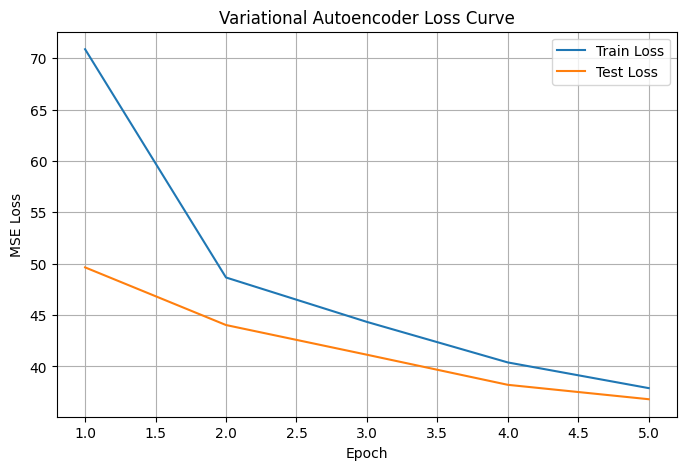

In [19]:
plot_loss_curves(
    vae_history,
    "Variational Autoencoder Loss Curve",
    "images/tutorial_13_vae_loss.png"
)


## 16. Visualize VAE Denoising Results

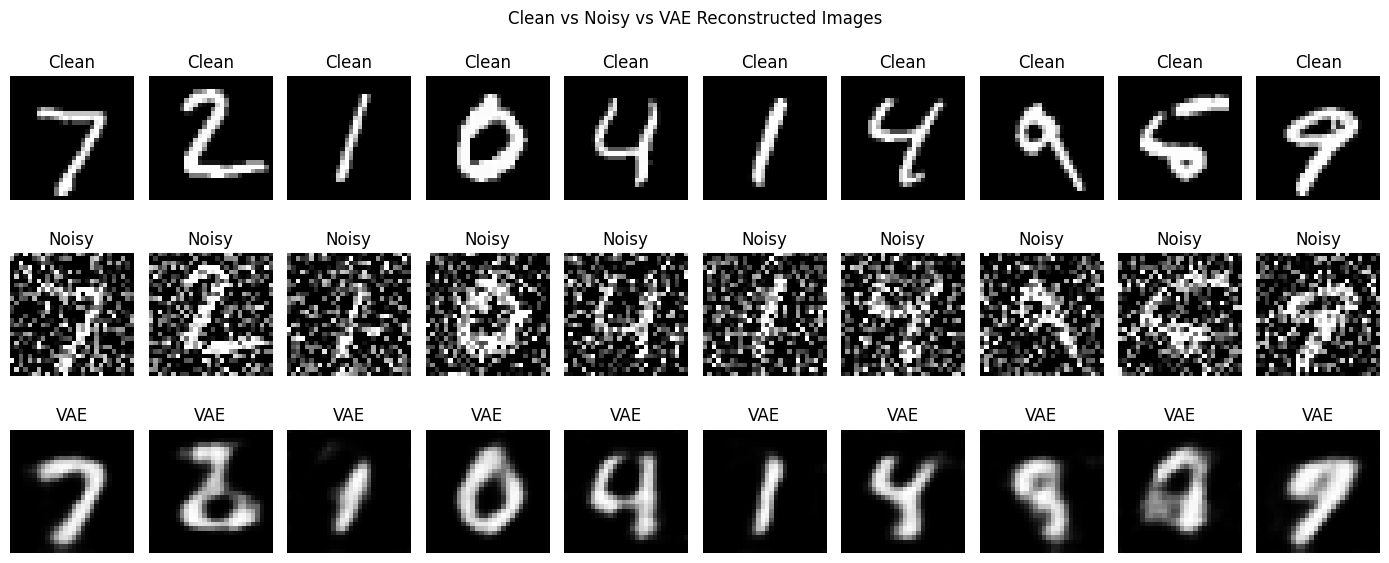

In [20]:
def visualize_vae_denoising_results(model, dataset, filename, n_images=10, noise_factor=0.5):
    model.eval()

    plt.figure(figsize=(14, 6))

    with torch.no_grad():
        for i in range(n_images):
            clean_image, _ = dataset[i]
            noisy_image = add_noise(clean_image.unsqueeze(0), noise_factor=noise_factor)
            reconstructed, _, _ = model(noisy_image.to(device))
            reconstructed = reconstructed.cpu().squeeze()

            plt.subplot(3, n_images, i + 1)
            plt.imshow(clean_image.squeeze(), cmap="gray")
            plt.title("Clean")
            plt.axis("off")

            plt.subplot(3, n_images, i + 1 + n_images)
            plt.imshow(noisy_image.squeeze(), cmap="gray")
            plt.title("Noisy")
            plt.axis("off")

            plt.subplot(3, n_images, i + 1 + 2 * n_images)
            plt.imshow(reconstructed, cmap="gray")
            plt.title("VAE")
            plt.axis("off")

    plt.suptitle("Clean vs Noisy vs VAE Reconstructed Images")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_vae_denoising_results(
    vae,
    test_dataset_used,
    filename="images/tutorial_13_vae_denoising_results.png",
    n_images=10,
    noise_factor=0.5
)


## 17. Generate New Images from the VAE Latent Space

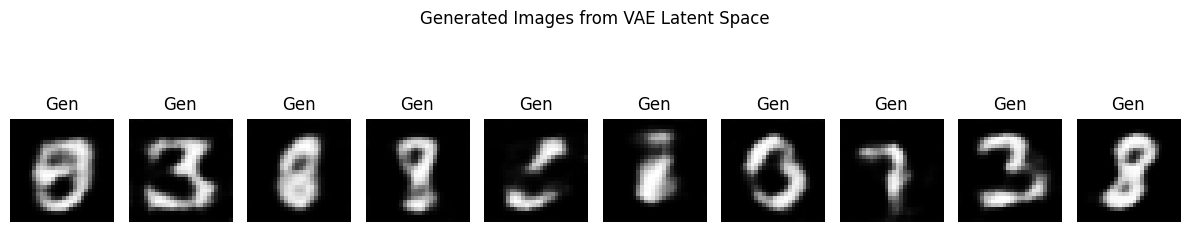

In [21]:
def generate_vae_samples(model, filename, n_images=10):
    model.eval()

    with torch.no_grad():
        z = torch.randn(n_images, model.latent_dim).to(device)
        generated_images = model.decode(z).cpu()

    plt.figure(figsize=(12, 3))

    for i in range(n_images):
        plt.subplot(1, n_images, i + 1)
        plt.imshow(generated_images[i].squeeze(), cmap="gray")
        plt.title("Gen")
        plt.axis("off")

    plt.suptitle("Generated Images from VAE Latent Space")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


generate_vae_samples(
    vae,
    filename="images/tutorial_13_vae_generated_samples.png",
    n_images=10
)


## 18. Compare All Models

In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Basic DAE",
        "Type": "Denoising Autoencoder",
        "Trainable Parameters": count_trainable_parameters(basic_dae),
        "Final Train Loss": basic_history["train_loss"][-1],
        "Final Test Loss": basic_history["test_loss"][-1],
        "Training Time (s)": basic_time
    },
    {
        "Model": "Deep DAE",
        "Type": "Deep Denoising Autoencoder",
        "Trainable Parameters": count_trainable_parameters(deep_dae),
        "Final Train Loss": deep_history["train_loss"][-1],
        "Final Test Loss": deep_history["test_loss"][-1],
        "Training Time (s)": deep_time
    },
    {
        "Model": "VAE",
        "Type": "Variational Autoencoder",
        "Trainable Parameters": count_trainable_parameters(vae),
        "Final Train Loss": vae_history["train_loss"][-1],
        "Final Test Loss": vae_history["test_loss"][-1],
        "Training Time (s)": vae_time
    }
])

comparison_df


,Model,Type,Trainable Parameters,Final Train Loss,Final Test Loss,Training Time (s)
0,Basic DAE,Denoising Autoencoder,29249,0.016825,0.016517,16.026650
1,Deep DAE,Deep Denoising Autoencoder,222561,0.010131,0.010034,19.278501
2,VAE,Variational Autoencoder,182945,37.885256,36.805836,17.022336


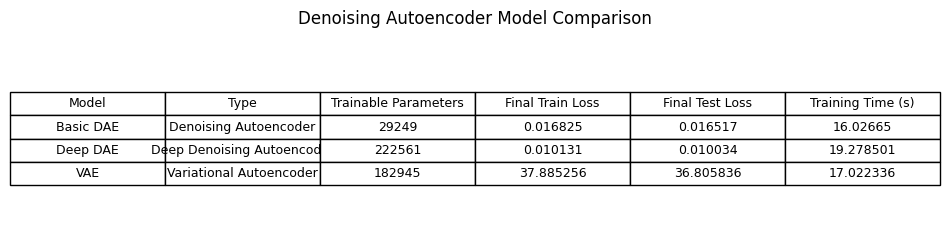

In [23]:
def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 2.0)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


comparison_image_df = comparison_df.copy()

for column in ["Final Train Loss", "Final Test Loss", "Training Time (s)"]:
    comparison_image_df[column] = comparison_image_df[column].round(6)

save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_13_model_comparison_table.png",
    title="Denoising Autoencoder Model Comparison"
)


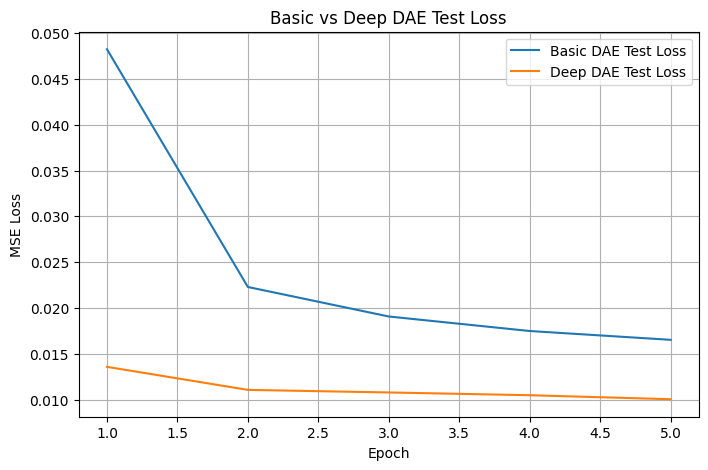

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(basic_history["test_loss"]) + 1), basic_history["test_loss"], label="Basic DAE Test Loss")
plt.plot(range(1, len(deep_history["test_loss"]) + 1), deep_history["test_loss"], label="Deep DAE Test Loss")

# VAE loss scale is different because it includes KL divergence and summed reconstruction loss
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Basic vs Deep DAE Test Loss")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_13_basic_vs_deep_loss.png", dpi=300, bbox_inches="tight")
plt.show()


# Final Observations

## Basic Denoising Autoencoder

The basic denoising autoencoder learned to reconstruct clean MNIST digits from noisy inputs.

## Deep Denoising Autoencoder

The deep autoencoder used more layers and batch normalization.  
This increased model capacity and improved denoising quality.

## Variational Autoencoder

The VAE learned a probabilistic latent space.  
It can reconstruct noisy images and also generate new samples from random latent vectors.

## Key Learning

Denoising autoencoders are useful because they learn robust representations of images.  
Instead of simply copying the input, the model learns to remove corruption/noise and recover the original clean image.
